# The infinite horizon on the PrOMMiS mixer-settler

Rare earth elements are recovered from an acidic leach solution by
liquid-liquid extraction: the aqueous leachate is contacted with an
organic solvent, kerosene carrying the extractant DEHPA, which pulls the
rare earth ions across the phase boundary and leaves the impurities
behind. The model is the mixer-settler solvent extraction unit from
[PrOMMiS](https://github.com/prommis/prommis), posed directly on
PrOMMiS's chemistry: one extraction stage, with the feed composition of a
coal-refuse leachate carrying nine rare earths (Sc, Y, La, Ce, Pr, Nd,
Sm, Gd, Dy) at milligram-per-liter levels under percent-level Al, Ca,
and Fe impurities in sulfuric acid.

This page solves one infinite-horizon problem on that stage: a single
sampling element of finite horizon with the terminal segment carrying
the rest of the transient. The setpoint comes from the model's own
steady state, and the plant's own scaling makes the solve possible.

## The process

One stage is three vessels. The two phases meet only in the mixer, a
stirred tank both phases share; each effluent then passes through its
own settler, modeled as four well-mixed tanks in series, the
disengagement lag between the mixer and the outlets carried as a
residence-time distribution.

```
                    +--------------+       aqueous settler
 aqueous feed ----->|              |--aq-->[T1]-[T2]-[T3]-[T4]--> raffinate
 (leachate)         |    mixer     |
 organic feed ----->|  (2 phases)  |--org->[T1]-[T2]-[T3]-[T4]--> loaded solvent
 (kerosene+DEHPA)   |              |       organic settler
                    +--------------+
```

In the mixer the metals distribute between the phases through the DEHPA
complexation equilibria, metal ions trading places with protons, so
extraction pushes acid back into the aqueous phase. The aqueous effluent
(the raffinate) carries what was not extracted out through its settler
cascade; the organic effluent (the loaded solvent) carries the rare
earth complexes out through the other. In a multi-stage train the
organic stream runs backward through the stage sequence, making the
train counter-current; this example runs one stage.

## The dynamics

Every equation the model solves, mixer first. For phase $p$ (aqueous or
organic) with volume fraction $\theta_p$ of the vessel volume $V$, species
$j$ with molar holdup $n_j$ and mass concentration $c_j$, and phase
volumetric flows $F_{in}$ and $F$:

**Inventories.** The states are the amounts the reactions cannot change.
Transfer moves a metal between phases without changing its total, so each
element $e$ carries one balance for its total across both phases, closed
by flows alone:

$$\frac{dN_e}{dt} = F_{aq}^{in} c_e^{feed} - F_{aq}\, c_e^{aq}
+ F_{og}^{in} c_{e,o}^{feed} - F_{og}\, c_e^{og}, \qquad
N_e = n_e^{aq} + n_e^{og}.$$

Hydrogen, sulfur, and the extractant get the same treatment through
their reaction invariants — extraction trades $z_e$ protons per
metal ion and binds $z_e$ extractant molecules per complex, and the
bisulfate dissociation trades within the acid system:

$$N_H = n_H + n_{HSO_4} - \sum_e z_e\, n_e^{og}, \qquad
N_S = n_{SO_4} + n_{HSO_4}, \qquad
N_A = n_{DEHPA} + \sum_e z_e\, n_e^{og}.$$

Water and chloride are inert and keep their plain holdup balances. Each
holdup ties to its concentration and phase volume, $n_j = V \theta_p
c_j / M_j$.

**The vessel and the withdrawal.** The phases fill the tank, and they
leave it in proportion to their fractions (the outlet flows $F^{aq}$,
$F^{og}$):

$$\theta_{aq} + \theta_{og} = 1, \qquad \theta_{aq}\, F^{og} =
\theta_{og}\, F^{aq}.$$

The second equation is a modeling choice, not conservation: it says the
dispersion is drawn off uniformly. Through it the phase split tracks the
flow ratio, so moving the two feeds apart re-partitions the tank; within
this example's control bounds the aqueous fraction can range from 0.375
to 0.625.

**The solvents.** Both bulk concentrations are constants by assumption:

$$c_{H_2O} = 10^6\ \mathrm{mg/L}, \qquad c_{Kerosene} = 8.2\times 10^5\
\mathrm{mg/L}.$$

With $c_{H_2O}$ constant, the water holdup is $V\,\theta_{aq}\,c_{H_2O}$:
proportional to the phase fraction, which is why it is the inventory that
remembers the split. The kerosene holdup is locked to the water holdup
through the split, so its balance reduces to an algebraic row that
determines the organic outlet flow.

**The acid chemistry** (aqueous, molar concentrations):

$$K_{a2}\, c_{HSO_4} = c_H\, c_{SO_4}, \qquad 10^{-\mathrm{pH}} = c_H\
[\mathrm{mol/L}].$$

**The metal transfer.** Per element $e$, the phases sit on the
distribution equilibrium in molar concentrations:

$$\frac{c_e^{og}}{M_{e,o}} = D_e\, \frac{c_e^{aq}}{M_e}, \qquad
\log_{10} D_e = (m_{0,e} + m_{1,e}\,d)\,\mathrm{pH} + B_{0,e} +
B_{1,e}\log_{10} d$$

with the correlation in pH and the extractant dosage $d$ (volume
percent) for the rare earths except scandium; Sc, Al, Ca, and Fe carry
constant fitted coefficients. There
is no rate law anywhere, and no transfer variable either: given each
total, the equilibrium splits it between the phases algebraically at
every instant. Extraction trades metal ions for protons, so the
equilibria couple back into the acid chemistry through pH.

**The settlers.** Four well-mixed tanks in series per phase, transport
only, each tank of volume $A\,\Delta x$ fed by the one before it:

$$A\,\Delta x\,\frac{dc_i}{dt} = F\,(c_{i-1} - c_i),$$

one balance per species per tank; the aqueous tanks also carry the
dissociation, so hydrogen and sulfur ride their combinations there too.

**Which inventories are states.** The 129 states are the mixer's twelve
metal totals, its hydrogen, sulfur, and extractant combinations, its
water and chloride holdups, and per settler tank the metals, chloride,
and the hydrogen and sulfur combinations on the aqueous side, every
species but kerosene on the organic side. Everything else —
concentrations, per-phase holdups, flows, the phase split — is algebra
the solver reconstructs at each instant.

## The declared model

[`models/prommis_sx_index_one.py`](models/prommis_sx_index_one.py) writes the stage
directly in Pyomo, with PrOMMiS supplying the chemistry: the feed
compositions, molar masses, distribution correlations, dissociation
constant, and reaction stoichiometry are read out of PrOMMiS's own
parameter and reaction packages at build time. Posing the balances on
the reaction invariants makes the model an index-one DAE — no
transfer extents, and nothing undetermined at the first time point.
The module declares the 129 states above, both feed flows as the
manipulated inputs (with their operating limits as bounds), and
additive zero-mean noise terms in the state balances as the declared
disturbances.

In [1]:
import pyomo.environ as pyo
import pyomo_pounce  # registers the pounce solver with Pyomo

import drto
from models.prommis_sx_index_one import build, scaled_solve, F_AQ, F_OG

m = build(N=1, h=0.25)
drto.info(m)

<drto registry>
states: 129, controls: 2
declarations:
  horizon: time (ContinuousSet, 4 points)
  states: nt_metal_La (free), nt_metal_Y (free), nt_metal_Pr (free), nt_metal_Ce (free), nt_metal_Nd (free), nt_metal_Sm (free), nt_metal_Gd (free), nt_metal_Dy (free), nt_metal_Al (free), nt_metal_Ca (free), nt_metal_Fe (free), nt_metal_Sc (free), nt_h (free), nt_s (free), nt_a (free), n_aq_H2O (free), n_aq_Cl (free), sn_aq_1_La (free), sn_aq_1_Y (free), sn_aq_1_Pr (free), sn_aq_1_Ce (free), sn_aq_1_Nd (free), sn_aq_1_Sm (free), sn_aq_1_Gd (free), sn_aq_1_Dy (free), sn_aq_1_Al (free), sn_aq_1_Ca (free), sn_aq_1_Fe (free), sn_aq_1_Sc (free), sn_aq_1_Cl (free), sn_aq_2_La (free), sn_aq_2_Y (free), sn_aq_2_Pr (free), sn_aq_2_Ce (free), sn_aq_2_Nd (free), sn_aq_2_Sm (free), sn_aq_2_Gd (free), sn_aq_2_Dy (free), sn_aq_2_Al (free), sn_aq_2_Ca (free), sn_aq_2_Fe (free), sn_aq_2_Sc (free), sn_aq_2_Cl (free), sn_aq_3_La (free), sn_aq_3_Y (free), sn_aq_3_Pr (free), sn_aq_3_Ce (free), sn_aq_3_Nd (free), sn_aq_3_Sm (free), sn_aq_3_Gd (free), sn_aq_3_Dy (free), sn_aq_3_Al (free), sn_aq_3_Ca (free), sn_aq_3_Fe (free), sn_aq_3_Sc (free), sn_aq_3_Cl (free), sn_aq_4_La (free), sn_aq_4_Y (free), sn_aq_4_Pr (free), sn_aq_4_Ce (free), sn_aq_4_Nd (free), sn_aq_4_Sm (free), sn_aq_4_Gd (free), sn_aq_4_Dy (free), sn_aq_4_Al (free), sn_aq_4_Ca (free), sn_aq_4_Fe (free), sn_aq_4_Sc (free), sn_aq_4_Cl (free), snt_h_1 (free), snt_h_2 (free), snt_h_3 (free), snt_h_4 (free), snt_s_1 (free), snt_s_2 (free), snt_s_3 (free), snt_s_4 (free), sn_og_1_DEHPA (free), sn_og_1_Al_o (free), sn_og_1_Ca_o (free), sn_og_1_Fe_o (free), sn_og_1_Sc_o (free), sn_og_1_Y_o (free), sn_og_1_La_o (free), sn_og_1_Ce_o (free), sn_og_1_Pr_o (free), sn_og_1_Nd_o (free), sn_og_1_Sm_o (free), sn_og_1_Gd_o (free), sn_og_1_Dy_o (free), sn_og_2_DEHPA (free), sn_og_2_Al_o (free), sn_og_2_Ca_o (free), sn_og_2_Fe_o (free), sn_og_2_Sc_o (free), sn_og_2_Y_o (free), sn_og_2_La_o (free), sn_og_2_Ce_o (free), sn_og_2_Pr_o (free), sn_og_2_Nd_o (free), sn_og_2_Sm_o (free), sn_og_2_Gd_o (free), sn_og_2_Dy_o (free), sn_og_3_DEHPA (free), sn_og_3_Al_o (free), sn_og_3_Ca_o (free), sn_og_3_Fe_o (free), sn_og_3_Sc_o (free), sn_og_3_Y_o (free), sn_og_3_La_o (free), sn_og_3_Ce_o (free), sn_og_3_Pr_o (free), sn_og_3_Nd_o (free), sn_og_3_Sm_o (free), sn_og_3_Gd_o (free), sn_og_3_Dy_o (free), sn_og_4_DEHPA (free), sn_og_4_Al_o (free), sn_og_4_Ca_o (free), sn_og_4_Fe_o (free), sn_og_4_Sc_o (free), sn_og_4_Y_o (free), sn_og_4_La_o (free), sn_og_4_Ce_o (free), sn_og_4_Pr_o (free), sn_og_4_Nd_o (free), sn_og_4_Sm_o (free), sn_og_4_Gd_o (free), sn_og_4_Dy_o (free)
  dynamics: dnt_metal[t,e]  ==  (0.986*aq_feed[t] - F_aq[t]*c_aq[t,e])/138.905 + (0.000105*og_feed[t] - F_og[t]*c_og[t,La_o])/138.905 + w_metal[t,e]  for t in time, e in E
  dynamics: dnt_h[t]  ==  10.75*aq_feed[t] - F_aq[t]*c_aq[t,H] + (10000.0*aq_feed[t] - F_aq[t]*c_aq[t,HSO4])/97.0 - (3*((0.000105*og_feed[t] - F_og[t]*c_og[t,La_o])/138.905) + 3*((2.179e-05*og_feed[t] - F_og[t]*c_og[t,Y_o])/88.905) + 3*((3.711e-05*og_feed[t] - F_og[t]*c_og[t,Pr_o])/140.907) + 3*((0.00031*og_feed[t] - F_og[t]*c_og[t,Ce_o])/140.11599999999999) + 3*((0.000165*og_feed[t] - F_og[t]*c_og[t,Nd_o])/144.24200000000002) + 3*((1.701e-05*og_feed[t] - F_og[t]*c_og[t,Sm_o])/150.35999999999999) + 3*((3.357e-05*og_feed[t] - F_og[t]*c_og[t,Gd_o])/157.25) + 3*((8.008e-06*og_feed[t] - F_og[t]*c_og[t,Dy_o])/162.5) + 3*((1.267e-05*og_feed[t] - F_og[t]*c_og[t,Al_o])/26.982) + 2*((2.684e-05*og_feed[t] - F_og[t]*c_og[t,Ca_o])/40.078) + 3*((2.873e-06*og_feed[t] - F_og[t]*c_og[t,Fe_o])/55.845) + 3*((1.734*og_feed[t] - F_og[t]*c_og[t,Sc_o])/44.946)) + w_h[t]  for t in time
  dynamics: dnt_s[t]  ==  (100*aq_feed[t] - F_aq[t]*c_aq[t,SO4])/96.0 + (10000.0*aq_feed[t] - F_aq[t]*c_aq[t,HSO4])/97.0 + w_s[t]  for t in time
  dynamics: dnt_a[t]  ==  3*((0.000105*og_feed[t] - F_og[t]*c_og[t,La_o])/138.905) + 3*((2.179e-05*og_feed[t] - F_og[t]*c_og[t,Y_o])/88.905) + 3*((3.711e-05*og_feed[t] - F_og[t]*c_og[t,P

## The setpoint

The operating point comes from the model itself, in three steps.

`drto.steady_state_simulation` reduces a clone to the fixed-input
equilibrium: time collapses through `drto.dynamic_to_steady_state`, every
accumulation is pinned at zero, the two feeds are fixed at their nominal
rates, the tracking costs and terminal constraint leave, and a constant
zero objective goes in. What remains is the square problem whose solution
is the equilibrium at those inputs.

`drto.initialize_steady_state` fills it block by block, ordering the
equations by what determines what and solving each group in turn, so
every group starts from values the preceding ones produced. The chemistry
spans twelve orders of magnitude in concentration, so a solve from the
build's crude guesses has nowhere to start.

The system is then solved from that point, and the tracking targets and
the initial condition are read off the solution through the
declarations: each `steady_state` pairing names a state and the Param
holding its setpoint, and each initial-condition constraint names a state
member and the Param a loop overwrites. The dynamic model keeps its own
values; the cold start fills them in the next cell.

In [2]:
# reduce to the fixed-input equilibrium: the controls are held, the
# costs and terminal constraint leave, and the zero objective goes in
sm = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.og_feed: F_OG, m.aq_feed: F_AQ})

# initialize
print(drto.initialize_steady_state(sm))

# solve
res = scaled_solve(sm, tee=True)
print("steady solve:", res.solver.termination_condition)

reg, reg_s = drto.info(m), drto.info(sm)
t0 = m.time.first()

# each steady_state pairing names a state and the Param holding its
# setpoint; the reduced model's records line up by declaration order
steady = {}
for kind in ("steady_state", "steady_state_control"):
    for here, there in zip(reg.declarations(kind), reg_s.declarations(kind)):
        v = there["of"]
        value = pyo.value(next(iter(v.values())) if v.is_indexed() else v)
        here["component"].set_value(value)
        steady[id(here["of"][t0])] = value

# each initial-condition constraint equates a state member with the Param
# a loop overwrites: start the run at the operating point
for con in reg.components("initial_condition"):
    for cd in (con.values() if con.is_indexed() else (con,)):
        lhs, rhs = cd.expr.args
        param, state = (rhs, lhs) if rhs.is_parameter_type() else (lhs, rhs)
        param.set_value(steady[id(state)])

print()
print(f"aqueous fraction {pyo.value(sm.th_aq):.4f}, "
      f"pH {pyo.value(sm.pH):.4f}, "
      f"Sc total {pyo.value(m.ss_metal_Sc):.6e} mol")

pyomo-pounce initialize (fill -> repair -> block-solve)
  decisions held: 0
  values filled : 0
  projection    : optimal
  pyomo-pounce block_initialize
    decisions fixed   : 0
    system square     : True
    blocks solved     : 295 (285 by Newton 1x1, 10 subsystem solves)
    vars initialized  : 344
    left untouched    : 0 underdetermined, 0 overdetermined
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, 

## The infinite-horizon problem

An off-spec start: the mixer holds half again the rare earth inventory
of the operating point, an upstream upset that just cleared. The
terminal segment is appended, the model cold-started from the off-spec
state onto the targets, the optimization assembled, and the horizon
solved once, a single sampling element of finite horizon with the
infinite tail carrying the rest of the transient.

`scaled_solve` assigns the scaling factors and hands the problem to
pounce under `nlp_scaling_method=user-scaling`, which reads them and
solves in the model's own units.

In [3]:
for j in ("Sc", "Y", "La", "Ce", "Pr", "Nd", "Sm", "Gd", "Dy"):
    m.ic_metal[j] = 1.5 * pyo.value(m.ic_metal[j])

pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
drto.cold_start_dynamic(m)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
res = scaled_solve(m, tee=True, options={"tol": 1e-6})
print(res.solver.termination_condition)

component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This i

## The planned trajectories

The horizon drives the rare earth inventories from the upset back toward
the operating point, the two feed flows doing the work. Filled markers
are the finite horizon, open markers the terminal segment mapped back to
real time, and the dotted lines the setpoints.

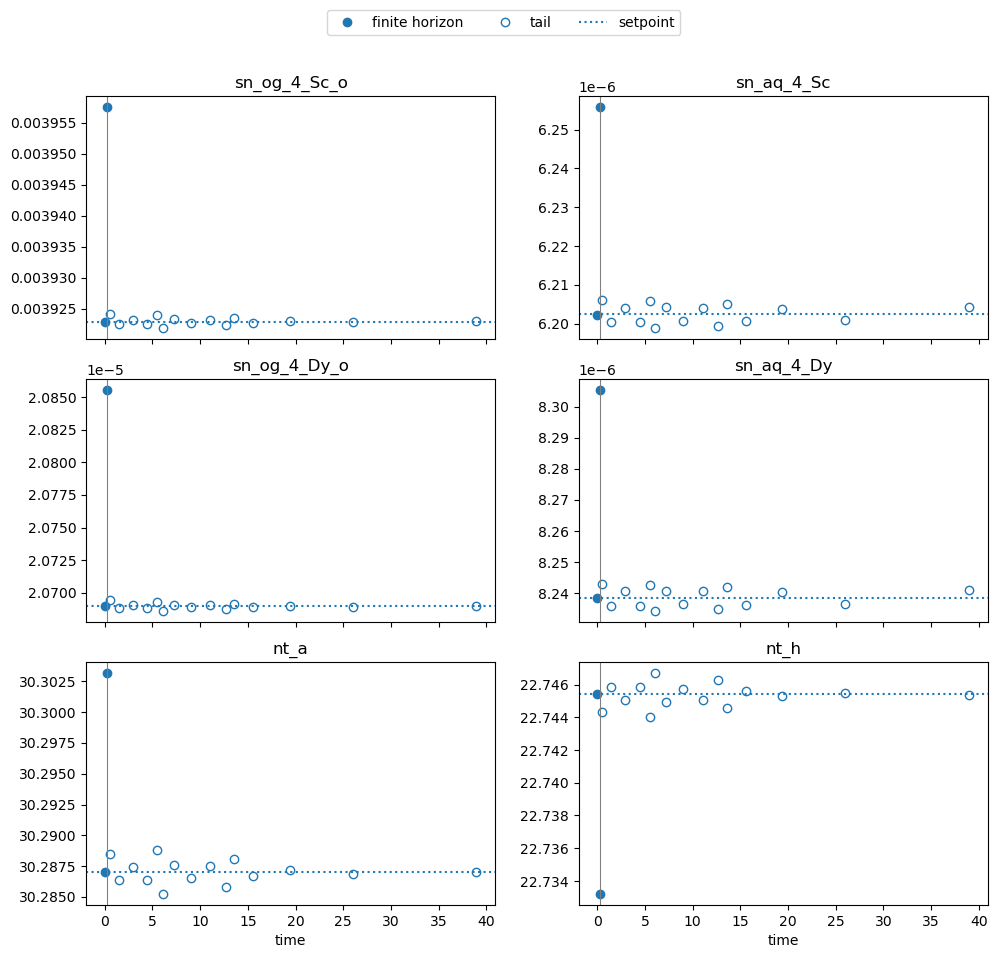

In [4]:
# six of the 129, at the two outlets where the separation shows:
# scandium and dysprosium in the loaded solvent leaving the
# organic settler, the same two in the raffinate leaving the
# aqueous settler, and the mixer's extractant and acid, which the
# transfer trades against
axes = drto.plot_states(m, states=[
    "sn_og_4_Sc_o", "sn_aq_4_Sc",
    "sn_og_4_Dy_o", "sn_aq_4_Dy",
    "nt_a", "nt_h",
])

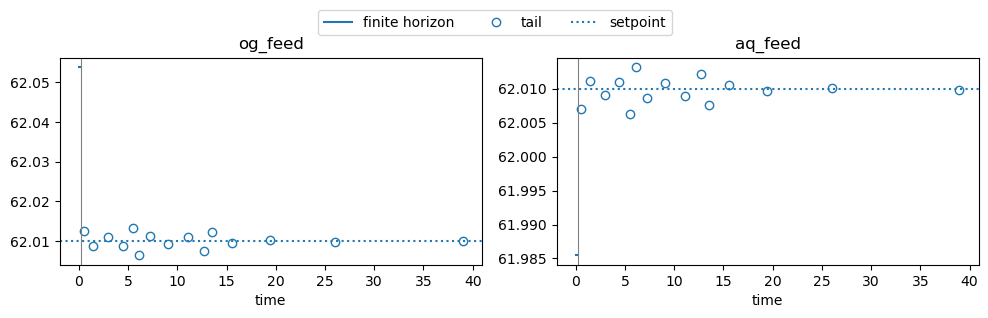

In [5]:
axes = drto.plot_controls(m)

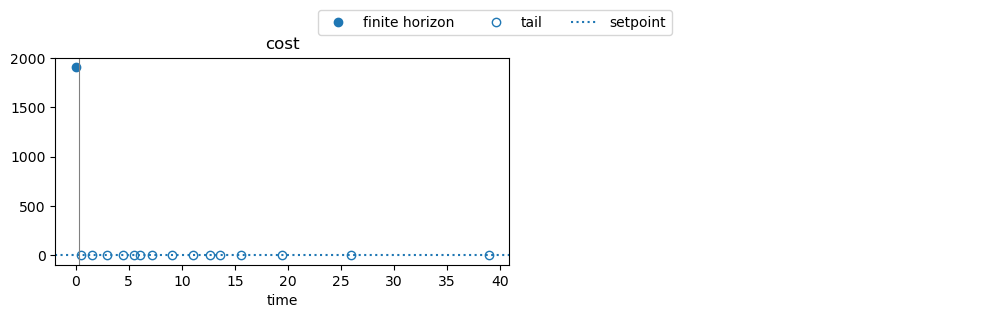

In [6]:
axes = drto.plot_stage_cost(m)